# Griffiths QM
## Chapter 3 — Visualizations

| Section | Problem |
|:--|:--|
| [3.13](#md_3_13) | Position & Momentum Representations — Fourier Duality |
| [3.14](#md_3_14) | Momentum-Space Wavefunction — Gaussian Packet |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift

plt.rcParams.update({'figure.dpi': 120, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'

# ── Shared helper: FFT-based Fourier transform pair ────────────────────
def ft_pair(psi, x, hbar=1.0):
    """Return (p_array, phi(p)) via FFT."""
    dx  = x[1] - x[0]
    phi = fftshift(fft(psi)) * dx / np.sqrt(2 * np.pi * hbar)
    k   = fftshift(fftfreq(len(x), d=dx)) * 2 * np.pi
    return hbar * k, phi

hbar = 1.0
N, L = 8192, 40.0
x    = np.linspace(-L/2, L/2, N, endpoint=False)

figures = []


---
## Problem 3.13 — Position & Momentum Representations: Fourier Duality {#md_3_13}

$$\phi(p) = \frac{1}{\sqrt{2\pi\hbar}}\int_{-\infty}^{\infty}\psi(x)\,e^{-ipx/\hbar}\,dx$$

Three representative wave functions $\psi(x)$ and their momentum-space counterparts $\phi(p)$
are plotted side by side. Note how **broad in $x$ ↔ narrow in $p$** and vice versa.


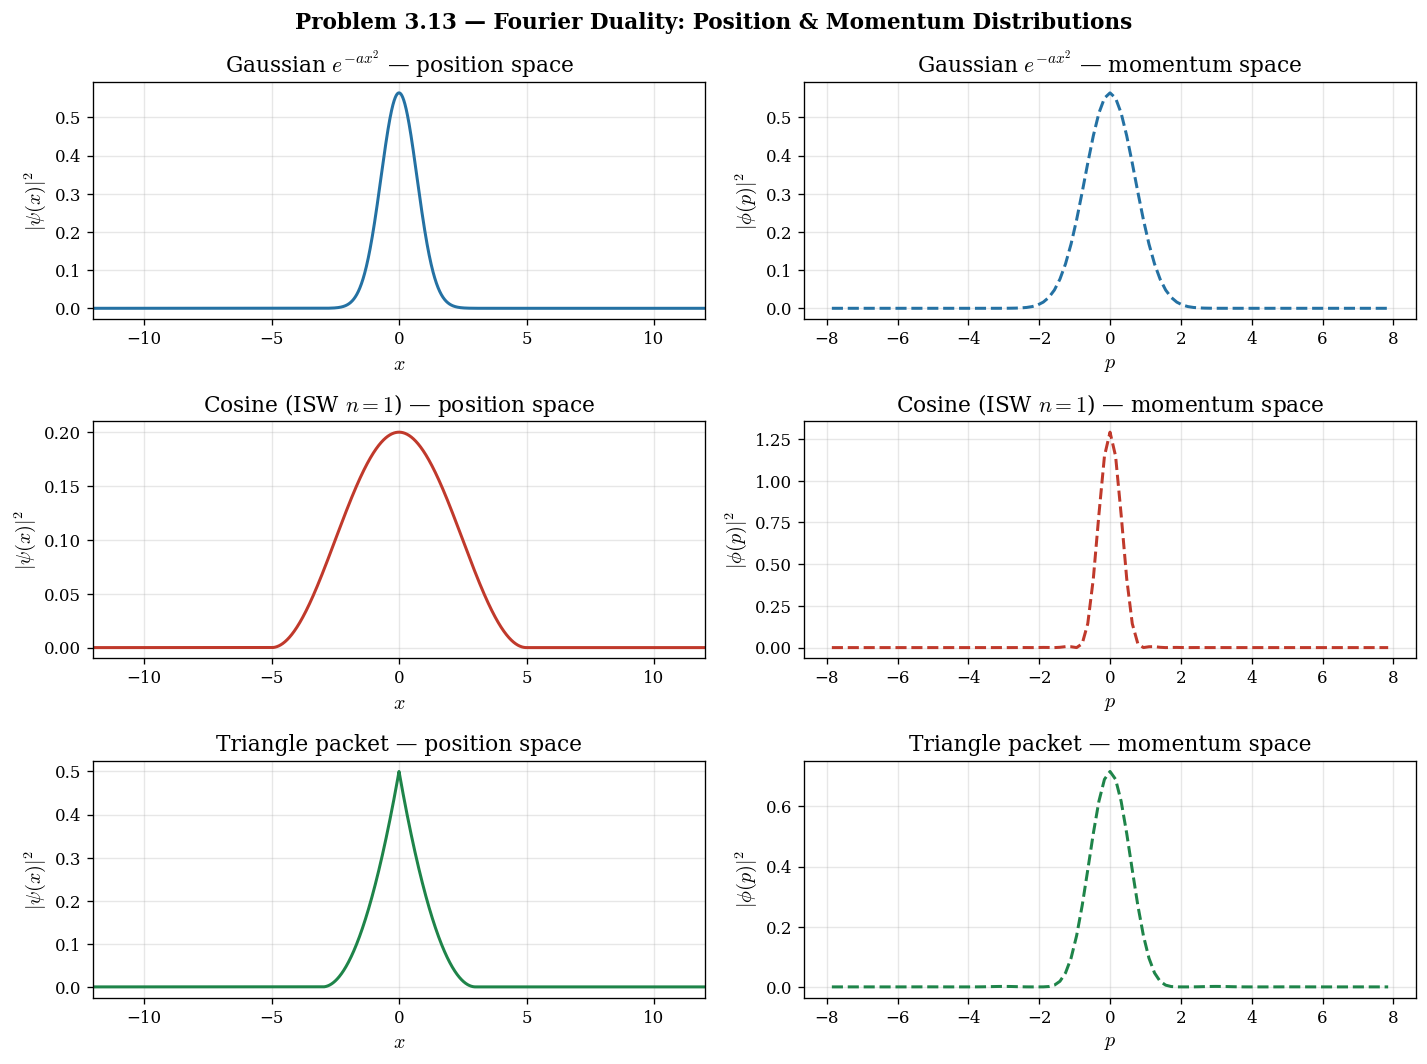

In [2]:
# ── Three ψ(x) and their φ(p) ─────────────────────────────────────────
a = 0.5
psi_g   = (2*a/np.pi)**0.25 * np.exp(-a * x**2)                 # Gaussian

psi_sq_raw = np.where(np.abs(x) < 5, np.cos(np.pi*x/10), 0.0)   # ISW n=1 on [-5,5]
psi_sq  = psi_sq_raw / np.sqrt(np.trapezoid(psi_sq_raw**2, x))

psi_tri_raw = np.where(np.abs(x) < 3, 1 - np.abs(x)/3, 0.0)     # triangle
psi_tri = psi_tri_raw / np.sqrt(np.trapezoid(psi_tri_raw**2, x))

wfns = [
    (psi_g,   r'Gaussian $e^{-ax^2}$',    BLUE),
    (psi_sq,  r'Cosine (ISW $n=1$)',       RED),
    (psi_tri, r'Triangle packet',          GREEN),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, (psi, label, color) in enumerate(wfns):
    p_arr, phi = ft_pair(psi, x)
    mask_p = np.abs(p_arr) < 8
    ax_x, ax_p = axes[row, 0], axes[row, 1]

    ax_x.plot(x, np.abs(psi)**2, color=color, lw=1.8)
    ax_x.set_xlim(-12, 12)
    ax_x.set_xlabel(r'$x$');  ax_x.set_ylabel(r'$|\psi(x)|^2$')
    ax_x.set_title(label + ' — position space'); ax_x.grid(True, alpha=0.3)

    ax_p.plot(p_arr[mask_p], np.abs(phi[mask_p])**2, color=color, lw=1.8, ls='--')
    ax_p.set_xlabel(r'$p$');  ax_p.set_ylabel(r'$|\phi(p)|^2$')
    ax_p.set_title(label + ' — momentum space'); ax_p.grid(True, alpha=0.3)

plt.suptitle('Problem 3.13 — Fourier Duality: Position & Momentum Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
figures.append((fig, 'fig_3_13a.png'))
plt.show()


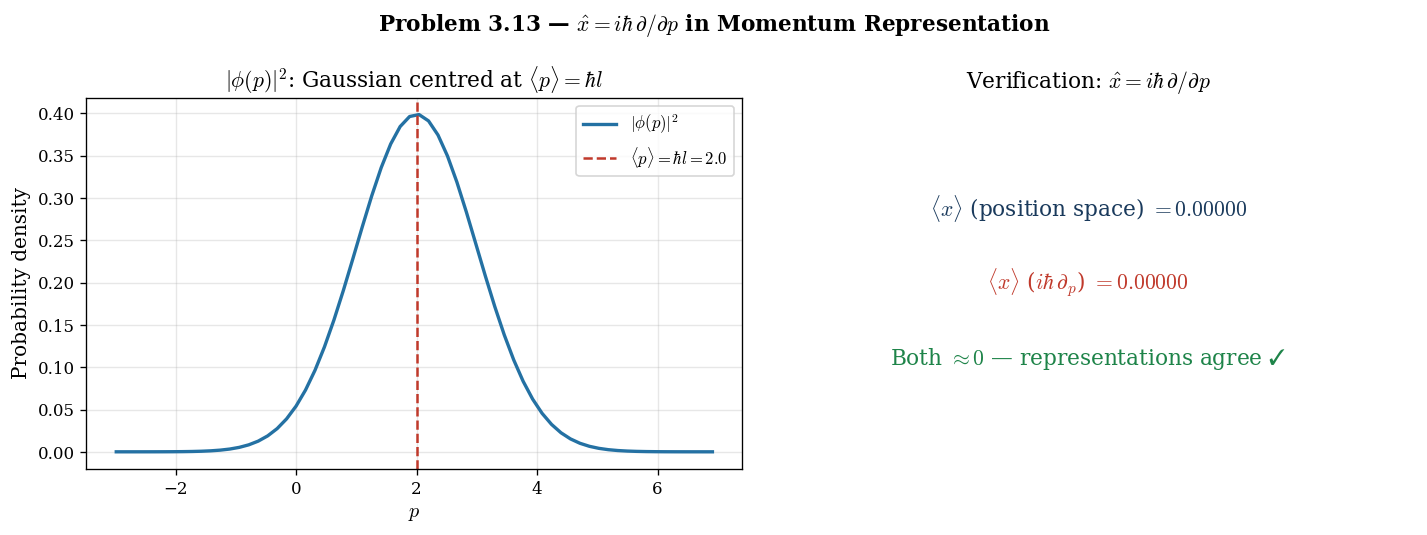

⟨x⟩ (position space)  = 0.000000
⟨x⟩ (momentum space)  = 0.000000


In [3]:
# ── Verify: x̂ = iħ ∂/∂p in momentum space ──────────────────────────
# Use ψ = A e^{-ax²+ilx}, ⟨x⟩ = 0  (parity)
a_v, l_v = 1.0, 2.0
psi_v = (2*a_v/np.pi)**0.25 * np.exp(-a_v*x**2 + 1j*l_v*x)
p_arr, phi_v = ft_pair(psi_v, x)

# ⟨x⟩ from position space
x_exp_x = float(np.real(np.trapezoid(np.conj(psi_v) * x * psi_v, x)))

# ⟨x⟩ from p-space: x̂ φ = iħ dφ/dp
dp       = p_arr[1] - p_arr[0]
dphi_dp  = np.gradient(phi_v, dp)
x_exp_p  = float(np.real(np.trapezoid(np.conj(phi_v) * (1j*hbar*dphi_dp), p_arr)))

mask_p = np.abs(p_arr - l_v) < 5
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(p_arr[mask_p], np.abs(phi_v[mask_p])**2, color=BLUE, lw=2,
             label=r'$|\phi(p)|^2$')
axes[0].axvline(l_v*hbar, color=RED, ls='--', lw=1.5,
                label=fr'$\langle p\rangle = \hbar l = {l_v}$')
axes[0].set_xlabel(r'$p$');  axes[0].set_ylabel('Probability density')
axes[0].set_title(r'$|\phi(p)|^2$: Gaussian centred at $\langle p\rangle = \hbar l$')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

axes[1].axis('off')
axes[1].set_title(r'Verification: $\hat{x} = i\hbar\,\partial/\partial p$')
for y, txt, color in [
    (0.68, fr'$\langle x\rangle$ (position space) $= {x_exp_x:.5f}$', NAVY),
    (0.48, fr'$\langle x\rangle$ ($i\hbar\,\partial_p$) $= {x_exp_p:.5f}$', RED),
    (0.28, r'Both $\approx 0$ — representations agree $\checkmark$', GREEN),
]:
    axes[1].text(0.5, y, txt, transform=axes[1].transAxes,
                 ha='center', fontsize=13, color=color)

plt.suptitle(r'Problem 3.13 — $\hat{x} = i\hbar\,\partial/\partial p$ in Momentum Representation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
figures.append((fig, 'fig_3_13b.png'))
plt.show()

print(f"⟨x⟩ (position space)  = {x_exp_x:.6f}")
print(f"⟨x⟩ (momentum space)  = {x_exp_p:.6f}")


---
## Problem 3.14 — Momentum-Space Wavefunction: Gaussian Packet {#md_3_14}

$$\psi(x) = A\,e^{-ax^2+ilx}, \qquad A = \left(\frac{2a}{\pi}\right)^{1/4}$$

$$\phi(p) = \left(\frac{1}{2\pi\hbar^2 a}\right)^{1/4}
\exp\!\left(-\frac{(p-\hbar l)^2}{4a\hbar^2}\right)$$

Key result: $\sigma_x = \dfrac{1}{2\sqrt{a}}$, $\;\sigma_p = \hbar\sqrt{a}$,
$\;\sigma_x\sigma_p = \dfrac{\hbar}{2}$ for **all** $a$.


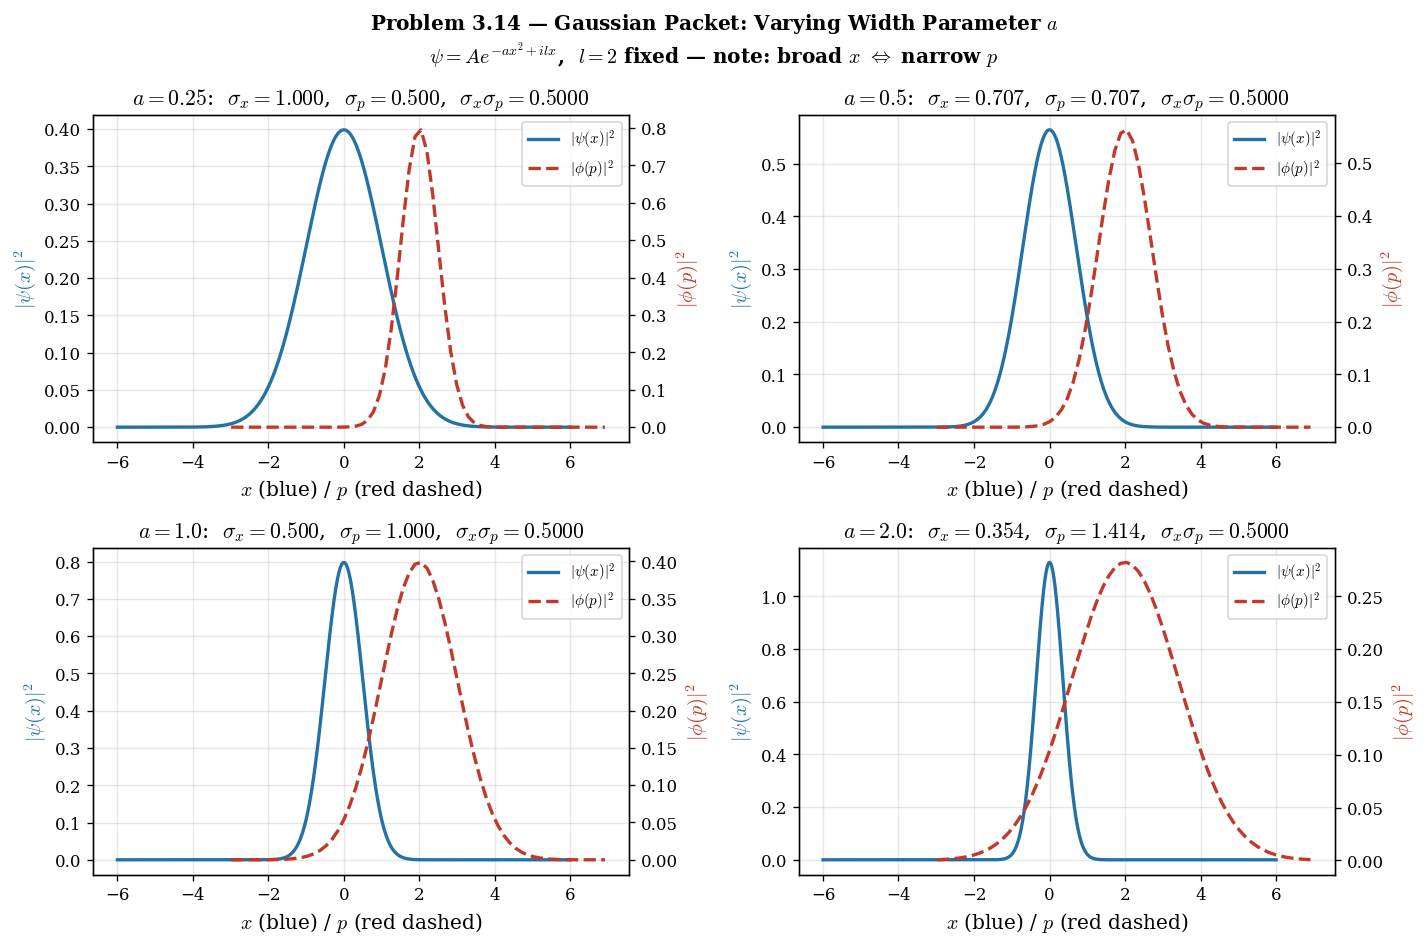

In [4]:
# ── Effect of width parameter a: σ_x σ_p = ħ/2 for all a ─────────────
l_fixed = 2.0
a_vals  = [0.25, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, a in enumerate(a_vals):
    psi = (2*a/np.pi)**0.25 * np.exp(-a*x**2 + 1j*l_fixed*x)
    p_arr, phi = ft_pair(psi, x)

    sigma_x = 1 / (2*np.sqrt(a))
    sigma_p = hbar * np.sqrt(a)

    mask_x = np.abs(x) < 6
    mask_p = np.abs(p_arr - l_fixed*hbar) < 5

    ax  = axes[idx]
    ax2 = ax.twinx()
    ax.plot(x[mask_x], np.abs(psi[mask_x])**2,
            color=BLUE, lw=2, label=r'$|\psi(x)|^2$')
    ax2.plot(p_arr[mask_p], np.abs(phi[mask_p])**2,
             color=RED, lw=2, ls='--', label=r'$|\phi(p)|^2$')

    ax.set_xlabel(r'$x$ (blue) / $p$ (red dashed)')
    ax.set_ylabel(r'$|\psi(x)|^2$', color=BLUE)
    ax2.set_ylabel(r'$|\phi(p)|^2$', color=RED)
    ax.set_title(fr'$a={a}$:  $\sigma_x={sigma_x:.3f}$,  '
                 fr'$\sigma_p={sigma_p:.3f}$,  '
                 fr'$\sigma_x\sigma_p={sigma_x*sigma_p:.4f}$')
    ax.grid(True, alpha=0.3)
    # Combine legends
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)

plt.suptitle(r'Problem 3.14 — Gaussian Packet: Varying Width Parameter $a$' + '\n' +
             r'$\psi=Ae^{-ax^2+ilx}$,  $l=2$ fixed — note: broad $x$ $\Leftrightarrow$ narrow $p$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
figures.append((fig, 'fig_3_14a.png'))
plt.show()


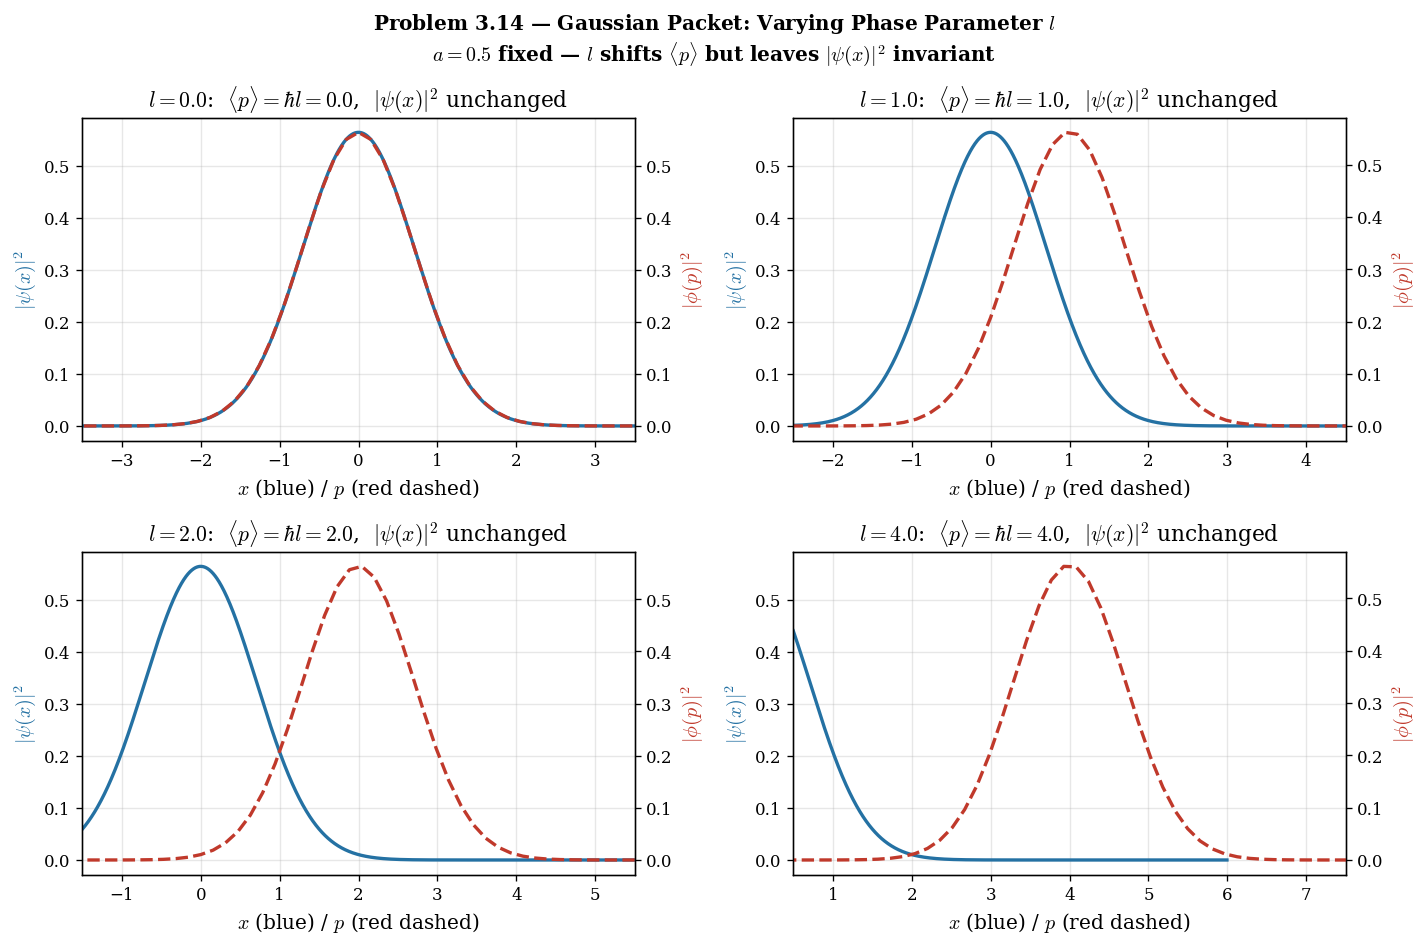

In [5]:
# ── Effect of phase parameter l: only shifts ⟨p⟩, not |ψ(x)|² ────────
a_fixed = 0.5
l_vals  = [0.0, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, l_v in enumerate(l_vals):
    psi = (2*a_fixed/np.pi)**0.25 * np.exp(-a_fixed*x**2 + 1j*l_v*x)
    p_arr, phi = ft_pair(psi, x)

    mask_x = np.abs(x) < 6
    p_center = l_v * hbar
    mask_p   = np.abs(p_arr - p_center) < 4

    ax  = axes[idx]
    ax2 = ax.twinx()
    ax.plot(x[mask_x], np.abs(psi[mask_x])**2, color=BLUE, lw=2)
    if mask_p.sum() > 20:
        ax2.plot(p_arr[mask_p], np.abs(phi[mask_p])**2,
                 color=RED, lw=2, ls='--')

    ax.set_xlabel(r'$x$ (blue) / $p$ (red dashed)')
    ax.set_ylabel(r'$|\psi(x)|^2$', color=BLUE)
    ax2.set_ylabel(r'$|\phi(p)|^2$', color=RED)
    ax2.set_xlim(p_center - 3.5, p_center + 3.5)
    ax.set_title(fr'$l={l_v}$:  $\langle p\rangle = \hbar l = {l_v}$,  '
                 r'$|\psi(x)|^2$ unchanged')
    ax.grid(True, alpha=0.3)

plt.suptitle(r'Problem 3.14 — Gaussian Packet: Varying Phase Parameter $l$' + '\n' +
             r'$a=0.5$ fixed — $l$ shifts $\langle p\rangle$ but leaves $|\psi(x)|^2$ invariant',
             fontsize=12, fontweight='bold')
plt.tight_layout()
figures.append((fig, 'fig_3_14b.png'))
plt.show()


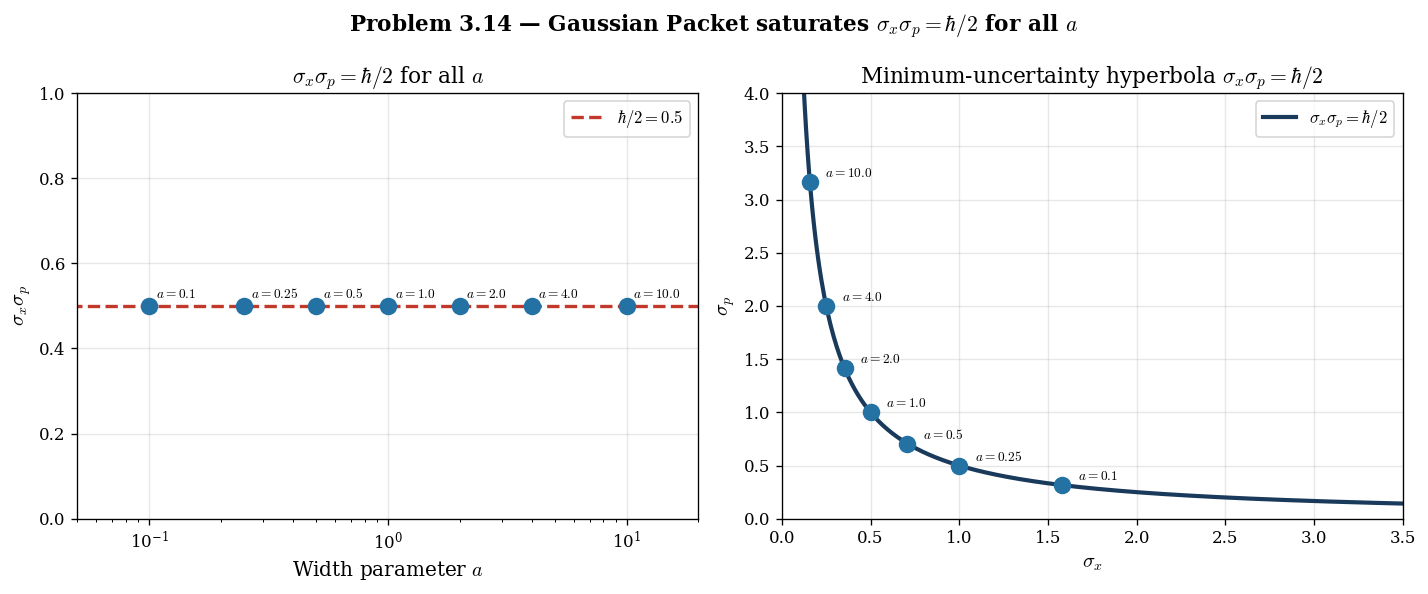

σ_x · σ_p for each a:
  a= 0.10:  0.500000
  a= 0.25:  0.500000
  a= 0.50:  0.500000
  a= 1.00:  0.500000
  a= 2.00:  0.500000
  a= 4.00:  0.500000
  a=10.00:  0.500000


In [6]:
# ── Minimum-uncertainty hyperbola σ_x σ_p = ħ/2 ──────────────────────
a_vals2 = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0]
sigma_x_vals = [1/(2*np.sqrt(a)) for a in a_vals2]
sigma_p_vals = [hbar*np.sqrt(a)  for a in a_vals2]
products     = [sx*sp for sx,sp in zip(sigma_x_vals, sigma_p_vals)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: product vs a (should be flat at ħ/2 = 0.5)
a_cont = np.logspace(-2, 2, 400)
ax = axes[0]
ax.semilogx(a_cont, np.ones_like(a_cont)*0.5,
            color=RED, ls='--', lw=2, label=r'$\hbar/2 = 0.5$')
ax.scatter(a_vals2, products, s=90, color=BLUE, zorder=5)
for a, p in zip(a_vals2, products):
    ax.annotate(fr'$a={a}$', (a, p),
                textcoords='offset points', xytext=(4, 5), fontsize=8)
ax.set_xlim(5e-2, 2e1); ax.set_ylim(0, 1.0)
ax.set_xlabel(r'Width parameter $a$'); ax.set_ylabel(r'$\sigma_x\sigma_p$')
ax.set_title(r'$\sigma_x\sigma_p = \hbar/2$ for all $a$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: σ_x vs σ_p hyperbola
sx_h = np.linspace(0.05, 3.5, 400)
ax2 = axes[1]
ax2.plot(sx_h, 0.5/sx_h, color=NAVY, lw=2.5, label=r'$\sigma_x\sigma_p=\hbar/2$')
ax2.scatter(sigma_x_vals, sigma_p_vals, s=90, color=BLUE, zorder=5)
for a, sx, sp in zip(a_vals2, sigma_x_vals, sigma_p_vals):
    ax2.annotate(fr'$a={a}$', (sx +0.05, sp),
                 textcoords='offset points', xytext=(4, 3), fontsize=8)
ax2.set_xlim(0, 3.5); ax2.set_ylim(0, 4)
ax2.set_xlabel(r'$\sigma_x$'); ax2.set_ylabel(r'$\sigma_p$')
ax2.set_title(r'Minimum-uncertainty hyperbola $\sigma_x\sigma_p = \hbar/2$')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(r'Problem 3.14 — Gaussian Packet saturates $\sigma_x\sigma_p = \hbar/2$ for all $a$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
figures.append((fig, 'fig_3_14c.png'))
plt.show()

print("σ_x · σ_p for each a:")
for a, p in zip(a_vals2, products):
    print(f"  a={a:5.2f}:  {p:.6f}")


---
## Save All Figures & Download as ZIP


In [7]:
import os, zipfile

save_dir = 'ch03_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch03_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch03_figures/fig_3_13a.png
Saved: ch03_figures/fig_3_13b.png
Saved: ch03_figures/fig_3_14a.png
Saved: ch03_figures/fig_3_14b.png
Saved: ch03_figures/fig_3_14c.png
Zip: ch03_figures.zip,  Files: ['fig_3_13a.png', 'fig_3_13b.png', 'fig_3_14a.png', 'fig_3_14b.png', 'fig_3_14c.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
